# EEG-Based Epileptic Seizure Classification

**CS4200 Final Project | Gabriel Jackson | August 2026**

This notebook develops an observation-level classification pipeline for the **Bangalore EEG Epilepsy Dataset (BEED)**. It answers two related questions:

1. Can the 16 supplied EEG-channel variables distinguish healthy observations from seizure-related observations?
2. How much performance is lost when the original four labels are retained instead of being collapsed into a binary target?

The workflow includes data validation, exploratory analysis, leakage-safe preprocessing, baseline comparison, repeated cross-validation, selective tuning, held-out evaluation, error analysis, and comparison with the introductory SeqBoostNet study. The CSV does not include subject or recording identifiers, so all results describe held-out **rows**, not verified performance on new patients or clinical diagnostic validity.

In [1]:
from pathlib import Path
import json
import os
import platform
import time
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/beed-matplotlib")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TEST_SIZE = 0.20
FEATURES = [f"X{i}" for i in range(1, 17)]
TARGET = "y"
CLASS_NAMES = {
    0: "Healthy",
    1: "Generalized seizure",
    2: "Focal seizure",
    3: "Seizure event",
}
BINARY_NAMES = {0: "Healthy", 1: "Seizure activity"}
PALETTE = {
    "Healthy": "#2A9D8F",
    "Generalized seizure": "#E76F51",
    "Focal seizure": "#6A4C93",
    "Seizure event": "#E9C46A",
}

OUTPUT_DIR = Path("final_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

#Accepts the uploaded BEED data
data_candidates = [
    Path("BEED_Data.csv"),
  
]
data_path = next((path for path in data_candidates if path.is_file()), None)
if data_path is None:
    raise FileNotFoundError(
        "Place BEED_Data.csv in same dir as this notebook folder"
    )

df = pd.read_csv(data_path)
expected_columns = FEATURES + [TARGET]
if list(df.columns) != expected_columns:
    raise ValueError(f"Expected {expected_columns}, but found {list(df.columns)}.")

print(f"Python {platform.python_version()} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print(f"Data file: {data_path} | Shape: {df.shape}")
display(df.head())

Python 3.13.13 | pandas 2.3.3 | scikit-learn 1.9.0
Data file: BEED_Data.csv | Shape: (8000, 17)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


## 1. Problem Definition, Source, and Data Quality

Epilepsy is a neurological disorder characterized by recurrent seizures. Automated analysis of EEG measurements may help identify patterns that deserve expert review, but a classroom model trained on de-identified rows is not a medical diagnostic system.

The UCI Machine Learning Repository describes BEED as a multivariate classification dataset recorded in Bangalore, India. The supplied CSV contains 8,000 rows, 16 integer predictors (`X1`-`X16`), and four balanced target categories. UCI also describes 80 individuals and 200 time points per subject, but the released rows do not contain subject, recording-session, time, electrode-name, or measurement-unit fields. This limits physiological validation and patient-independent testing.

The introductory study used engineered spectral and temporal features with a stacked SeqBoostNet model. This project deliberately tests whether a simpler, reproducible scikit-learn pipeline can learn useful row-level patterns from the 16 released variables.

In [2]:
#Verifies structure, numeric types, finite values, duplicates, and target labels.
numeric_df = df.apply(pd.to_numeric, errors="coerce")
quality_summary = pd.DataFrame({
    "Check": [
        "Rows", "Predictors", "Missing/nonnumeric values", "Infinite values",
        "Fully duplicated rows", "Predictor-duplicate rows", "Observed target labels",
    ],
    "Result": [
        len(df), len(FEATURES), int(numeric_df.isna().sum().sum()),
        int(np.isinf(numeric_df[FEATURES].to_numpy()).sum()),
        int(df.duplicated().sum()), int(df.duplicated(subset=FEATURES).sum()),
        str(sorted(df[TARGET].unique().tolist())),
    ],
})
display(quality_summary)

if numeric_df.isna().any().any() or np.isinf(numeric_df[FEATURES].to_numpy()).any():
    raise ValueError("Missing, nonnumeric, or infinite values require a revised cleaning plan.")
if set(df[TARGET].unique()) != {0, 1, 2, 3}:
    raise ValueError("The target must contain labels 0, 1, 2, and 3.")

df = numeric_df.copy()
df[TARGET] = df[TARGET].astype(int)
df["Class"] = df[TARGET].map(CLASS_NAMES)

#IQR flags describe extreme values(not grounds for automatic deletion).
outlier_counts = {}
for channel in FEATURES:
    q1, q3 = df[channel].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[channel] = int(((df[channel] < lower) | (df[channel] > upper)).sum())

validation_summary = {
    "rows": int(len(df)),
    "predictors": len(FEATURES),
    "missing_or_nonnumeric": int(df[FEATURES + [TARGET]].isna().sum().sum()),
    "infinite_predictor_values": int(np.isinf(df[FEATURES].to_numpy()).sum()),
    "full_duplicates": int(df[FEATURES + [TARGET]].duplicated().sum()),
    "iqr_flagged_predictor_values": int(sum(outlier_counts.values())),
    "class_counts": {str(k): int(v) for k, v in df[TARGET].value_counts().sort_index().items()},
}
(OUTPUT_DIR / "data_validation_summary.json").write_text(json.dumps(validation_summary, indent=2))

display(df[FEATURES].describe().T.round(2))

,Check,Result
0,Rows,8000
1,Predictors,16
2,Missing/nonnumeric values,0
3,Infinite values,0
4,Fully duplicated rows,0
5,Predictor-duplicate rows,0
6,Observed target labels,"[0, 1, 2, 3]"


,count,mean,std,min,25%,50%,75%,max
X1,8000.0,-1.49,36.82,-281.0,-7.0,0.0,8.0,252.0
X2,8000.0,-2.19,36.11,-255.0,-7.0,0.0,8.0,261.0
X3,8000.0,-3.24,35.80,-255.0,-7.0,-1.0,5.0,238.0
X4,8000.0,-4.12,36.29,-257.0,-10.0,-1.0,7.0,246.0
X5,8000.0,-1.82,37.62,-264.0,-10.0,0.0,10.0,249.0
X6,8000.0,-2.31,36.31,-277.0,-8.0,0.0,8.0,245.0
X7,8000.0,-3.40,36.36,-277.0,-8.0,-1.0,6.0,220.0
X8,8000.0,-3.45,36.52,-260.0,-7.0,-1.0,5.0,271.0
X9,8000.0,-1.65,38.11,-290.0,-7.0,0.0,8.0,280.0
X10,8000.0,-2.56,37.54,-302.0,-8.0,0.0,8.0,251.0


### Data-quality interpretation

No missing, nonnumeric, infinite, duplicated, or structurally inconsistent rows were detected. IQR-flagged extremes are retained because they may represent legitimate signal variation, and no documented error threshold justifies deleting them. These checks establish computational consistency only. Because channel units, named electrode mappings, recording configuration, and accepted physiological limits are not supplied in the CSV, the notebook does **not** claim that every value is physiologically valid.

## 2. Exploratory Data Analysis

EDA is performed on the original four classes so subtype information is not discarded before modeling. The plots focus on class balance, distribution shape, channel relationships, and low-dimensional structure.

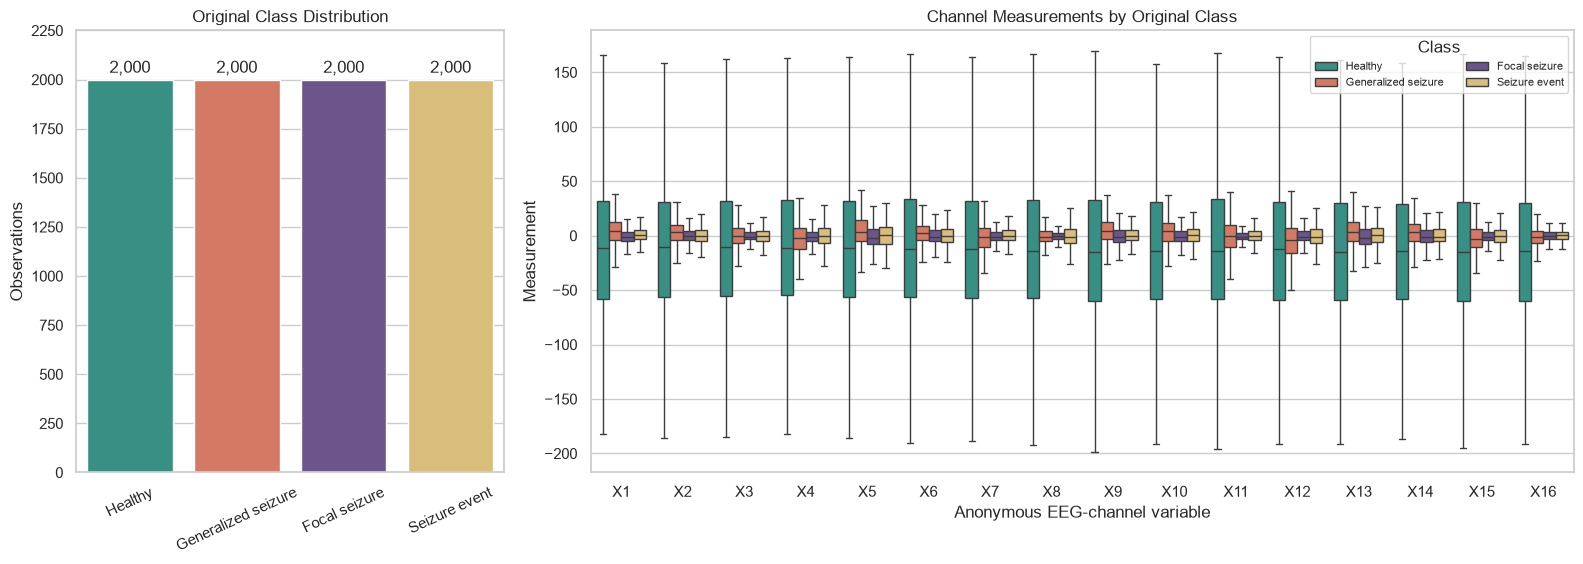

X1            X2            X3            X4         \
                      mean    std   mean    std   mean    std   mean    std   
Class                                                                         
Focal seizure        -0.74   8.72   0.12   6.29  -0.45   4.44  -0.64   5.88   
Generalized seizure   7.06  17.89   3.63  12.18   0.07  13.48  -3.70  15.65   
Healthy             -12.86  68.96 -12.33  69.17 -12.23  69.10 -12.30  69.00   
Seizure event         0.58   8.17  -0.18   9.93  -0.34   6.67   0.16  11.40   

                        X5         ...    X12           X13           X14  \
                      mean    std  ...   mean    std   mean    std   mean   
Class                              ...                                      
Focal seizure        -0.97  11.96  ...  -0.35   6.00  -0.32  13.91  -0.37   
Generalized seizure   6.02  18.26  ...  -4.85  19.00   5.55  17.78   3.65   
Healthy             -12.47  69.03  ... -13.87  70.28 -14.36  69.85 -14.74   
Seizure event         0.13  15.58  ...  -0.06  12.54   0.48  14.65  -0.18   

                              X15           X16         
                       std   mean    std   mean    std  
Class                                                   
Focal seizure         8.25  -0.67   5.15   0.04   3.88  
Generalized seizure  13.39  -1.81  12.73  -1.61   8.85  
Healthy              69.55 -14.73  69.66 -14.83  69.96  
Seizure event         9.55  -0.22   8.36  -0.05   4.87  

[4 rows x 32 columns]

In [3]:
class_order = list(CLASS_NAMES.values())

#Displays class balances and all-channel distributions.
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), gridspec_kw={"width_ratios": [1, 2.3]})
counts = df["Class"].value_counts().reindex(class_order)
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=PALETTE, legend=False, ax=axes[0])
axes[0].set(title="Original Class Distribution", xlabel="", ylabel="Observations")
axes[0].tick_params(axis="x", rotation=25)
for i, count in enumerate(counts):
    axes[0].text(i, count + 35, f"{count:,}", ha="center")
axes[0].set_ylim(0, 2250)

long_df = df.melt(id_vars="Class", value_vars=FEATURES,
                  var_name="Channel", value_name="Measurement")
sns.boxplot(data=long_df, x="Channel", y="Measurement", hue="Class",
            hue_order=class_order, palette=PALETTE, showfliers=False, ax=axes[1])
axes[1].set(title="Channel Measurements by Original Class",
            xlabel="Anonymous EEG-channel variable", ylabel="Measurement")
axes[1].legend(title="Class", ncols=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_class_and_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

class_summary = df.groupby("Class", observed=True)[FEATURES].agg(["mean", "std"])
display(class_summary.round(2))

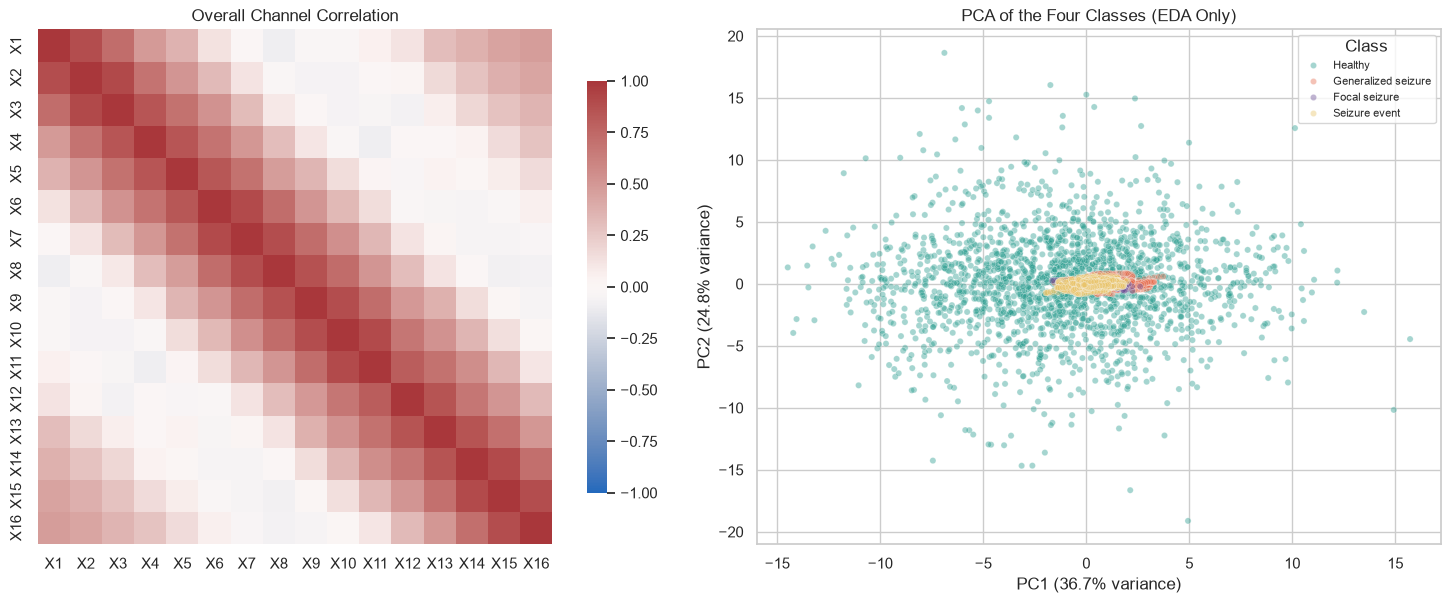

In [4]:
#Descriptive correlation and standardized PCA (PCA not used for modeling).
scaled = StandardScaler().fit_transform(df[FEATURES])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coordinates = pca.fit_transform(scaled)
explained = 100 * pca.explained_variance_ratio_
pca_df = pd.DataFrame({"PC1": coordinates[:, 0], "PC2": coordinates[:, 1], "Class": df["Class"]})

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
sns.heatmap(df[FEATURES].corr(), cmap="vlag", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title("Overall Channel Correlation")

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Class",
                hue_order=class_order, palette=PALETTE, alpha=0.42, s=20, ax=axes[1])
axes[1].set(
    title="PCA of the Four Classes (EDA Only)",
    xlabel=f"PC1 ({explained[0]:.1f}% variance)",
    ylabel=f"PC2 ({explained[1]:.1f}% variance)",
)
axes[1].legend(title="Class", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_correlation_and_pca.png", dpi=180, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_percent": explained,
}).to_csv(OUTPUT_DIR / "pca_explained_variance.csv", index=False)

### EDA findings

The dataset is balanced at 2,000 rows per original class. Healthy observations have the broadest distributions and a modest negative shift across the channel variables. Generalized-seizure observations are less dispersed, while focal-seizure and seizure-event observations are the most compact and overlap most strongly. Correlation remains visible among several predictors, so a single channel should not be interpreted in isolation. The first two standardized principal components explain about 61.5% of predictor variance; they separate some healthy observations but do not produce clean four-class clusters.

These findings support two model choices: Logistic Regression as an interpretable linear reference and Random Forest as a nonlinear model that can use thresholds and interactions. They also justify retaining both a four-class task and a secondary binary healthy-versus-seizure task.

## 3. Data Preparation and Experimental Design

All 16 predictors are retained. The original target is preserved for multiclass analysis; a binary copy maps class `0` to healthy and classes `1`-`3` to seizure activity. A single stratified 80/20 split based on the original labels gives both tasks exactly the same rows. Scaling occurs only inside the Logistic Regression pipeline. Random Forest receives the original values. Every transformation and tuning decision is learned from training data only.

In [5]:
X = df[FEATURES].copy()
y_multiclass = df[TARGET].copy()
y_binary = y_multiclass.ne(0).astype(int)

row_ids = np.arange(len(df))
train_ids, test_ids = train_test_split(
    row_ids,
    test_size=TEST_SIZE,
    stratify=y_multiclass,
    random_state=RANDOM_STATE,
)

#Stores label metadata once so every report and plot uses same order.
tasks = {
    "Four-class": {
        "y": y_multiclass,
        "labels": list(CLASS_NAMES),
        "display_names": list(CLASS_NAMES.values()),
    },
    "Binary": {
        "y": y_binary,
        "labels": list(BINARY_NAMES),
        "display_names": list(BINARY_NAMES.values()),
    },
}
#Splits rows into Training and Test
split_rows = []
for task_name, task in tasks.items():
    for split_name, ids in [("Training", train_ids), ("Test", test_ids)]:
        for label, count in task["y"].iloc[ids].value_counts().sort_index().items():
            label_position = task["labels"].index(int(label))
            split_rows.append({
                "Target": task_name,
                "Split": split_name,
                "Class": task["display_names"][label_position],
                "Observations": int(count),
            })

split_summary = pd.DataFrame(split_rows)
split_summary.to_csv(OUTPUT_DIR / "train_test_split_counts.csv", index=False)
display(split_summary)

,Target,Split,Class,Observations
0,Four-class,Training,Healthy,1600
1,Four-class,Training,Generalized seizure,1600
2,Four-class,Training,Focal seizure,1600
3,Four-class,Training,Seizure event,1600
4,Four-class,Test,Healthy,400
5,Four-class,Test,Generalized seizure,400
6,Four-class,Test,Focal seizure,400
7,Four-class,Test,Seizure event,400
8,Binary,Training,Healthy,1600
9,Binary,Training,Seizure activity,4800


## 4. Model Selection, Tuning, and Repeated Validation

- **Most-frequent Dummy Classifier:** establishes no-skill performance and exposes the binary target's 75% majority-class accuracy.
- **Logistic Regression:** provides a scaled, class-weighted linear benchmark. Its regularization strength (`C`) is tuned over a small grid.
- **Random Forest:** is the primary candidate because EDA suggests nonlinear class boundaries and interactions. A restrained grid varies tree count, depth, leaf size, and features considered per split.

Five-fold stratified grid search selects settings using **macro F1** on the training portion. The selected pipelines are then assessed with 5-fold cross-validation repeated three times. The test set is not used for tuning.

In [6]:
X_train, X_test = X.iloc[train_ids], X.iloc[test_ids]
tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=3, random_state=RANDOM_STATE
)
#Repeated CV measures to split sensitivity while keeping the experiment reproducible.
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
}


def model_searches():
    #Returns fresh leakage-safe searches for one target formulation.
    logistic = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE
        )),
    ])
    forest = Pipeline([
        ("model", RandomForestClassifier(
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1
        )),
    ])
    return {
        "Logistic Regression": GridSearchCV(
            logistic,
            {"model__C": [0.1, 1.0, 10.0]},
            scoring="f1_macro",
            cv=tuning_cv,
            n_jobs=-1,
            refit=True,
        ),
        "Random Forest": GridSearchCV(
            forest,
            {
                "model__n_estimators": [250, 400],
                "model__max_depth": [None, 16],
                "model__min_samples_leaf": [1, 2],
                "model__max_features": ["sqrt", 0.75],
            },
            scoring="f1_macro",
            cv=tuning_cv,
            n_jobs=-1,
            refit=True,
        ),
    }

selected_models = {}
tuning_rows = []
cv_rows = []

for task_name, task in tasks.items():
    y_train = task["y"].iloc[train_ids]
    selected_models[task_name] = {
        "Dummy baseline": Pipeline([
            ("model", DummyClassifier(strategy="most_frequent")),
        ])
    }

    for model_name, search in model_searches().items():
        started = time.perf_counter()
        search.fit(X_train, y_train)
        selected_models[task_name][model_name] = search.best_estimator_
        tuning_rows.append({
            "Target": task_name,
            "Model": model_name,  #search.best_score/params return dictionary of the values found during cross validation
            "Best CV macro F1": search.best_score_,
            "Best parameters": str(search.best_params_),
            "Search seconds": time.perf_counter() - started,
        })

    for model_name, model in selected_models[task_name].items():
        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=repeated_cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=True,
        )
        cv_rows.append({
            "Target": task_name,
            "Model": model_name,
            "Repeated CV accuracy mean": scores["test_accuracy"].mean(),
            "Repeated CV balanced accuracy mean": (
                scores["test_balanced_accuracy"].mean()
            ),
            "Repeated CV macro F1 mean": scores["test_macro_f1"].mean(),
            "Repeated CV macro F1 SD": scores["test_macro_f1"].std(),
            "Repeated CV train macro F1 mean": scores["train_macro_f1"].mean(),
        })

tuning_results = pd.DataFrame(tuning_rows)
cv_results = pd.DataFrame(cv_rows)
cv_results["Train-validation macro F1 gap"] = (
    cv_results["Repeated CV train macro F1 mean"]
    - cv_results["Repeated CV macro F1 mean"]
)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

tuning_results.to_csv(OUTPUT_DIR / "tuning_results.csv", index=False)
cv_results.to_csv(OUTPUT_DIR / "repeated_cv_results.csv", index=False)

display(tuning_results.round({"Best CV macro F1": 3, "Search seconds": 2}))
display(cv_results.round(3))

,Target,Model,Best CV macro F1,Best parameters,Search seconds
0,Four-class,Logistic Regression,0.482,{'model__C': 0.1},5.09
1,Four-class,Random Forest,0.957,"{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 400}",55.23
2,Binary,Logistic Regression,0.594,{'model__C': 0.1},0.13
3,Binary,Random Forest,0.998,"{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 250}",41.45


,Target,Model,Repeated CV accuracy mean,Repeated CV balanced accuracy mean,Repeated CV macro F1 mean,Repeated CV macro F1 SD,Repeated CV train macro F1 mean,Train-validation macro F1 gap
0,Four-class,Dummy baseline,0.250,0.250,0.100,0.000,0.100,0.000
1,Four-class,Logistic Regression,0.476,0.476,0.482,0.013,0.491,0.009
2,Four-class,Random Forest,0.958,0.958,0.958,0.008,1.000,0.042
3,Binary,Dummy baseline,0.750,0.500,0.429,0.000,0.429,0.000
4,Binary,Logistic Regression,0.637,0.626,0.591,0.011,0.594,0.003
5,Binary,Random Forest,0.998,0.997,0.997,0.002,1.000,0.003


Random Forest substantially outperformed Logistic Regression, supporting the EDA finding that the class boundaries are nonlinear. The binary Dummy Classifier reached 75% accuracy but only 0.429 macro F1, demonstrating why accuracy alone is misleading for the imbalanced binary target.

*Repeated CV is performed after hyperparameters were selected from the same training pool as a stability analysis, not a completely independent estimate of model-selection performance.*

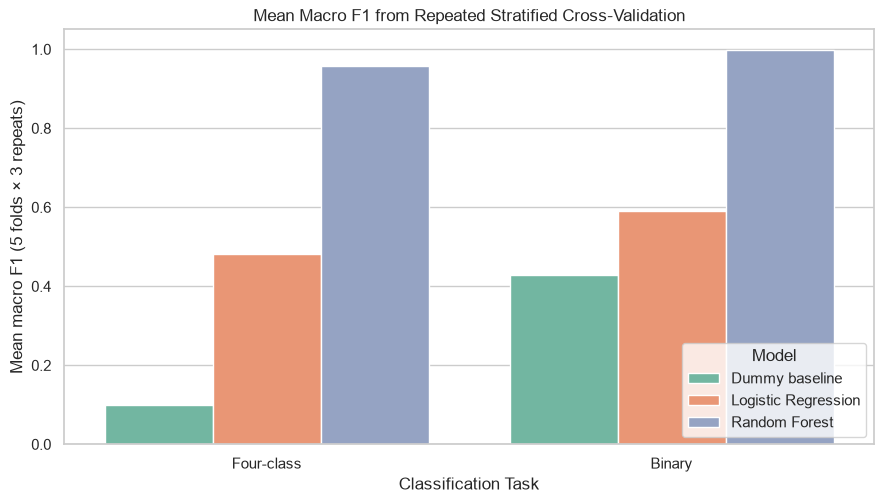

In [7]:
#Plots mean macro F1 across 15 validation evaluations and is
# generated by repeated stratified 5-fold cross-validation with 3 repeats.
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.barplot(
    data=cv_results,
    x="Target",
    y="Repeated CV macro F1 mean",
    hue="Model",
    palette="Set2",
    ax=ax,
)
ax.set(
    title="Mean Macro F1 from Repeated Stratified Cross-Validation",
    xlabel="Classification Task",
    ylabel="Mean macro F1 (5 folds × 3 repeats)",
    ylim=(0, 1.05),
)
ax.legend(title="Model", loc="lower right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "repeated_cv_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Final Performance Evaluation

Macro F1 and balanced accuracy are the primary metrics because they give equal weight to every class. Accuracy is still reported, but the binary Dummy Classifier shows why it cannot be used alone. Weighted F1 reflects frequency-weighted performance, while ROC-AUC measures probability ranking. Confusion matrices and class reports reveal which labels are confused.

,Target,Model,Accuracy,Balanced accuracy,Macro precision,Macro recall,Macro F1,Weighted F1,ROC-AUC
0,Four-class,Dummy baseline,0.250,0.250,0.062,0.250,0.100,0.100,0.500
1,Four-class,Logistic Regression,0.459,0.459,0.488,0.459,0.466,0.466,0.657
2,Four-class,Random Forest,0.962,0.962,0.963,0.962,0.963,0.963,0.998
3,Binary,Dummy baseline,0.750,0.500,0.375,0.500,0.429,0.643,0.500
4,Binary,Logistic Regression,0.615,0.602,0.578,0.602,0.569,0.639,0.650
5,Binary,Random Forest,0.999,0.998,0.999,0.998,0.998,0.999,1.000


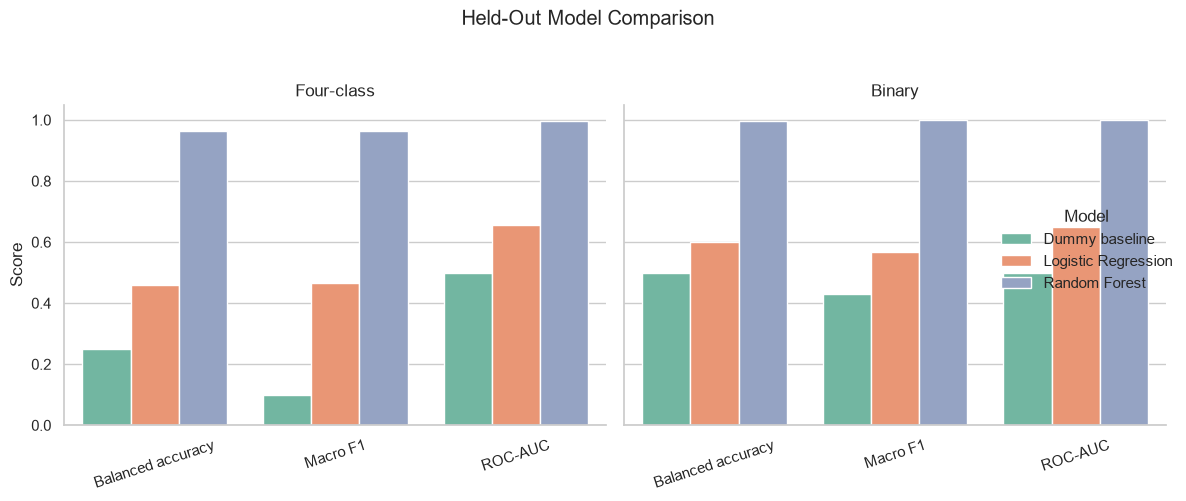

In [8]:
evaluation_rows = []
predictions = {}

for task_name, task in tasks.items():
    y_train = task["y"].iloc[train_ids]
    y_test = task["y"].iloc[test_ids]
    predictions[task_name] = {}

    for model_name, model in selected_models[task_name].items():
        model.fit(X_train, y_train)
        test_pred = model.predict(X_test)
        probabilities = model.predict_proba(X_test)

        if task_name == "Binary":
            auc = roc_auc_score(y_test, probabilities[:, 1])
        else:
            auc = roc_auc_score(
                y_test, probabilities, multi_class="ovr", average="macro"
            )

        predictions[task_name][model_name] = {
            "y_true": y_test,
            "predicted": test_pred,
            "probabilities": probabilities,
        }
        evaluation_rows.append({
            "Target": task_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, test_pred),
            "Balanced accuracy": balanced_accuracy_score(y_test, test_pred),
            "Macro precision": precision_score(
                y_test, test_pred, average="macro", zero_division=0
            ),
            "Macro recall": recall_score(
                y_test, test_pred, average="macro", zero_division=0
            ),
            "Macro F1": f1_score(y_test, test_pred, average="macro", zero_division=0),
            "Weighted F1": f1_score(y_test, test_pred, average="weighted", zero_division=0),
            "ROC-AUC": auc,
        })

test_results = pd.DataFrame(evaluation_rows)
test_results.to_csv(OUTPUT_DIR / "final_test_results.csv", index=False)
display(test_results.round(3))

#Final comparison centers on class-sensitive metrics.
plot_results = test_results.melt(
    id_vars=["Target", "Model"],
    value_vars=["Balanced accuracy", "Macro F1", "ROC-AUC"],
    var_name="Metric",
    value_name="Score",
)
grid = sns.catplot(
    data=plot_results,
    kind="bar",
    col="Target",
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2",
    errorbar=None,
    height=4.8,
    aspect=1.05,
)
grid.set_titles("{col_name}")
grid.set_axis_labels("", "Score")
grid.set(ylim=(0, 1.05))
for ax in grid.axes.flat:
    ax.tick_params(axis="x", rotation=18)
grid.fig.suptitle("Held-Out Model Comparison", y=1.04)
grid.fig.tight_layout()
grid.fig.savefig(OUTPUT_DIR / "final_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

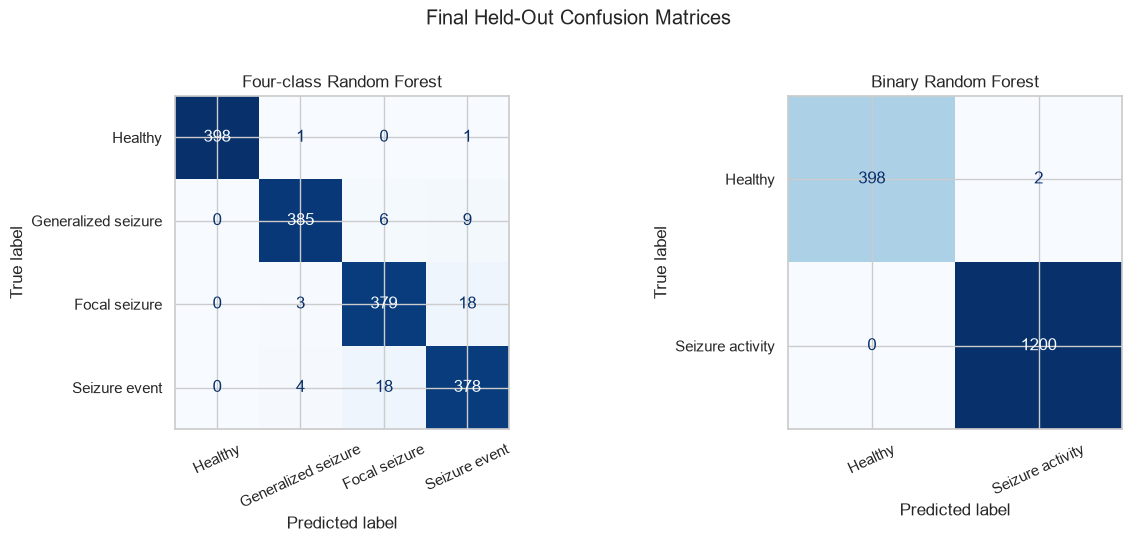

,precision,recall,f1-score,support
Four-class Random Forest,,,,
Healthy,1.000,0.995,0.997,400.000
Generalized seizure,0.980,0.962,0.971,400.000
Focal seizure,0.940,0.948,0.944,400.000
Seizure event,0.931,0.945,0.938,400.000
accuracy,0.962,0.962,0.962,0.962
macro avg,0.963,0.962,0.963,1600.000
weighted avg,0.963,0.962,0.963,1600.000


,precision,recall,f1-score,support
Binary Random Forest,,,,
Healthy,1.000,0.995,0.997,400.000
Seizure activity,0.998,1.000,0.999,1200.000
accuracy,0.999,0.999,0.999,0.999
macro avg,0.999,0.998,0.998,1600.000
weighted avg,0.999,0.999,0.999,1600.000


In [9]:
#Shows final Random Forest errors and class-specific results.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
for ax, (task_name, task) in zip(axes, tasks.items()):
    stored = predictions[task_name]["Random Forest"]
    ConfusionMatrixDisplay.from_predictions(
        stored["y_true"],
        stored["predicted"],
        labels=task["labels"],
        display_labels=task["display_names"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"{task_name} Random Forest")
    ax.tick_params(axis="x", rotation=25)
fig.suptitle("Final Held-Out Confusion Matrices", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "final_random_forest_confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()

for task_name, task in tasks.items():
    stored = predictions[task_name]["Random Forest"]
    report = classification_report(
        stored["y_true"],
        stored["predicted"],
        labels=task["labels"],
        target_names=task["display_names"],
        output_dict=True,
        zero_division=0,
    )
    report_table = pd.DataFrame(report).T.round(3)
    report_table.index.name = f"{task_name} Random Forest"
    display(report_table)
    report_table.to_csv(OUTPUT_DIR / f"{task_name.lower()}_random_forest_classification_report.csv")

## 6. Error Analysis, Interpretation, and Reference Comparison

Permutation importance measures the decrease in held-out macro F1 after one predictor is shuffled. It is preferable here to raw impurity importance, but correlated channels can still divide or mask importance. The anonymous channel names prevent anatomical claims.

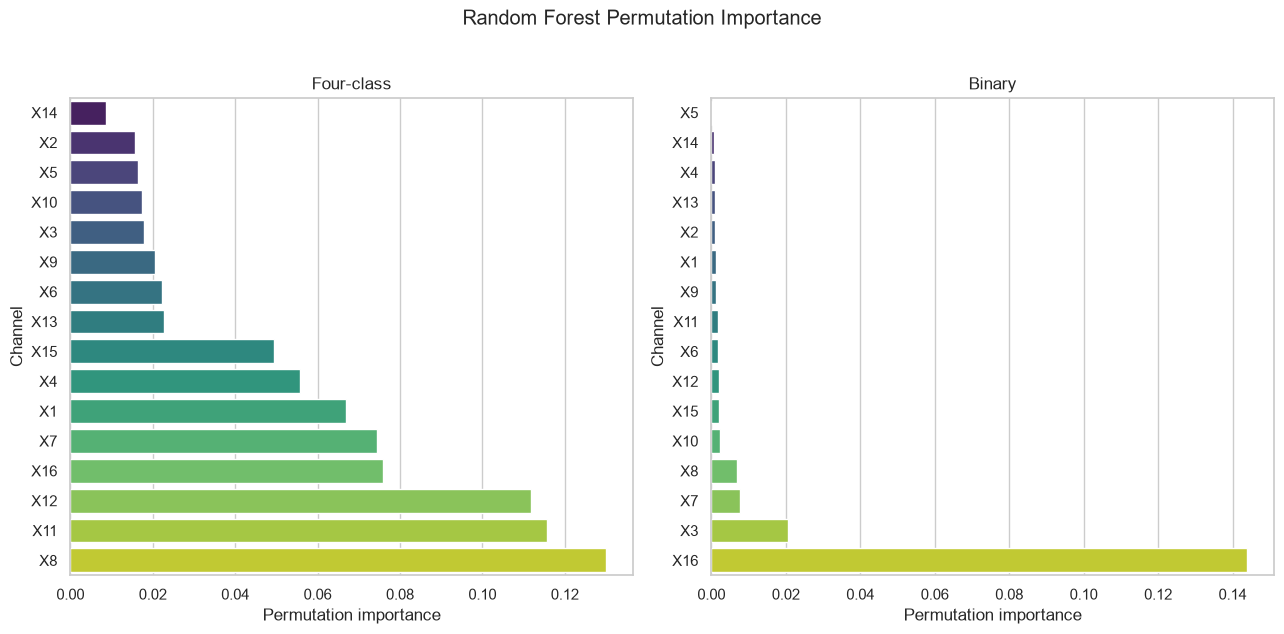

,Study / model,Task,Accuracy
0,SeqBoostNet source study,Average of six pairwise BEED cases,96.7%
1,SeqBoostNet source study,Generalized vs. focal (A1),95.9%
2,SeqBoostNet source study,Focal vs. seizure event (A4),91.2%
3,This project: tuned Random Forest,One four-class task,96.2%
4,This project: tuned Random Forest,Healthy vs. any seizure,99.9%


,Actual,Predicted,Count
7,Seizure event,Focal seizure,18
5,Focal seizure,Seizure event,18
3,Generalized seizure,Seizure event,9
2,Generalized seizure,Focal seizure,6
6,Seizure event,Generalized seizure,4
4,Focal seizure,Generalized seizure,3
0,Healthy,Generalized seizure,1
1,Healthy,Seizure event,1


In [10]:
importance_rows = []
for task_name, task in tasks.items():
    model = selected_models[task_name]["Random Forest"]
    result = permutation_importance(
        model,
        X_test,
        task["y"].iloc[test_ids],
        scoring="f1_macro",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    for channel, mean, std in zip(FEATURES, result.importances_mean, result.importances_std):
        importance_rows.append({
            "Target": task_name,
            "Channel": channel,
            "Permutation importance": mean,
            "Importance SD": std,
        })

importance = pd.DataFrame(importance_rows)
importance.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), sharex=False)
for ax, task_name in zip(axes, tasks):
    subset = importance[importance["Target"] == task_name].sort_values("Permutation importance")
    sns.barplot(data=subset, x="Permutation importance", y="Channel", hue="Channel",
                palette="viridis", legend=False, ax=ax)
    ax.set_title(task_name)
fig.suptitle("Random Forest Permutation Importance", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "permutation_importance.png", dpi=180, bbox_inches="tight")
plt.show()

#Contextual comparison only: the source study used six pairwise tasks and engineered features.
rf_test = test_results[test_results["Model"] == "Random Forest"].set_index("Target")
reference_comparison = pd.DataFrame([
    {"Study / model": "SeqBoostNet source study", "Task": "Average of six pairwise BEED cases", "Accuracy": 0.9671},
    {"Study / model": "SeqBoostNet source study", "Task": "Generalized vs. focal (A1)", "Accuracy": 0.9591},
    {"Study / model": "SeqBoostNet source study", "Task": "Focal vs. seizure event (A4)", "Accuracy": 0.9116},
    {"Study / model": "This project: tuned Random Forest", "Task": "One four-class task", "Accuracy": rf_test.loc["Four-class", "Accuracy"]},
    {"Study / model": "This project: tuned Random Forest", "Task": "Healthy vs. any seizure", "Accuracy": rf_test.loc["Binary", "Accuracy"]},
])
reference_comparison.to_csv(OUTPUT_DIR / "reference_model_comparison.csv", index=False)
display(reference_comparison.assign(Accuracy=lambda x: x["Accuracy"].map(lambda value: f"{value:.1%}")))

#Summarizes the largest off-diagonal four-class error.
four_true = predictions["Four-class"]["Random Forest"]["y_true"].to_numpy()
four_pred = predictions["Four-class"]["Random Forest"]["predicted"]
error_pairs = pd.DataFrame({"Actual": four_true, "Predicted": four_pred})
error_pairs = error_pairs[error_pairs["Actual"] != error_pairs["Predicted"]]
error_summary = (
    error_pairs.groupby(["Actual", "Predicted"]).size().rename("Count").reset_index()
)
error_summary["Actual"] = error_summary["Actual"].map(CLASS_NAMES)
error_summary["Predicted"] = error_summary["Predicted"].map(CLASS_NAMES)
error_summary = error_summary.sort_values("Count", ascending=False)
error_summary.to_csv(OUTPUT_DIR / "four_class_error_pairs.csv", index=False)
display(error_summary)

## Error Analysis:
The four-class Random Forest made 60 errors among 1,600 test observations. Thirty-six errors occurred specifically between focal seizure and seizure event, confirming that these were the most difficult categories to separate. The binary model made only two errors, both healthy observations classified as seizure activity; no seizure observations were missed in this split.

## 7. Results and Conclusion

The final results support three conclusions. First, both trained models learn more than class frequency, but Random Forest is clearly stronger than the linear benchmark. Second, binary healthy-versus-seizure classification is easier because it removes the need to distinguish overlapping seizure subtypes. Third, four-class performance remains strong enough that the original labels should not be discarded; focal seizure and seizure event remain the most important error pair.

The source paper's SeqBoostNet results provide useful context, but they are not a direct benchmark. That study used engineered spectral and temporal features, a stacked LSTM/XGBoost/Gradient-Boosting/AdaBoost architecture, and six pairwise BEED cases. This project uses the released 16-column table for one four-class task and one combined binary task. Similar percentages therefore do not establish that the simpler Random Forest matches or outperforms SeqBoostNet.

### Limitations

- Subject and recording identifiers are absent, so random row splitting may place correlated observations from one source in both partitions.
- The 16 predictors lack units and electrode mappings in the CSV. Structural validation does not establish physiological validity.
- Repeated stratified validation tests row-level stability, not generalization to new patients, sites, or acquisition systems.
- Permutation importance is predictive rather than causal or anatomical, particularly with correlated channels.
- The test set was held outside final tuning, but the same project split was observed during the preliminary milestone; an external or subject-grouped test set would be stronger evidence.

Within these limits, the tuned Random Forest is the best current model for observation-level classification. The binary formulation is appropriate for broad detection, while the four-class formulation preserves potentially useful subtype detail and remains a meaningful secondary result.

### References

Najmusseher, & Nizar Banu, P. K. (2025). Feature engineering for epileptic seizure classification using SeqBoostNet. *International Journal of Computing and Digital Systems, 17*(1), 1-15. https://doi.org/10.12785/ijcds/1571020131

World Health Organization. (2024, February 7). *Epilepsy*. https://www.who.int/news-room/fact-sheets/detail/epilepsy